# Metric information

This notebook examines how much information the four metrics share, and which properties of a protein
are associated with a prediction that lies far from its experimental structures. Machaon itself treats
its metrics as separate axes of one search space (Kakoulidis et al., *Commun Biol* 2023); the first
question tests whether they are in fact complementary here. Both questions are addressed with Information
Imbalance (Glielmo et al., *PNAS Nexus* 2022) and its differentiable extension, DII (Wild et al.,
*Nat Commun* 2025; DADApy), which compare the nearest-neighbour structure of two descriptions of the same
points. A value near 0 means that the first description contains the information of the second; a value
near 1 means that it contains none of it.

When both descriptions are built from the metrics themselves, the imbalance measures redundancy rather
than accuracy: a metric dominated by noise shares little with the others and therefore cannot be dropped.
Comparisons against an independent target (the Machaon metrics against RMSD, protein properties against
the distance of the prediction) are not affected by this. Metric values enter as standardised
log10(value + 10⁻⁴); because the comparisons of one protein share structures, section 1b repeats the
analysis with one comparison per protein.

**Input:** `results/comparisons.json`; section 3b also uses `results/t_alpha_pca.csv` from notebook 03.
The notebook runs in about 10–15 minutes.  
**Output:** `results/metric_information.json` and the figures in `results/figures/`.

In [1]:
import contextlib
import importlib.metadata as md
import io
import json
import os
import sys
import time
import warnings

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")
os.environ["TQDM_DISABLE"] = "1"  # DADApy shows a progress bar for every training

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm.auto, tqdm.std  # DADApy + ipywidgets would draw ~220 progress bars

tqdm.auto.tqdm = tqdm.std.tqdm
from dadapy.diff_imbalance import DiffImbalance

from src.analysis import experimental_structures, protein_table
from src.baselines import protein_max_gap
from src.figures import COLOR, apply_style, save
from src.information_imbalance import (
    METRICS,
    imbalance_table,
    information_imbalance,
    load_metric_matrix,
    log_standardise,
    one_per_protein,
    protein_covariates,
    subsample,
)

apply_style()

print(
    "dadapy",
    md.version("dadapy"),
    "| numpy",
    np.__version__,
    "| jax",
    md.version("jax"),
)
FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)
SEEDS = [0, 1, 2]  # three random subsamples / DII seeds
N_POINTS = 1000  # subsample size (DII works with N x N distance matrices)
K = 50  # DII neighbourhood size: ~5 % of the points (DADApy's rule of thumb)
NAMES = {
    "w_rdist_norm": "w-rdist",
    "b_phipsi": "b-phipsi",
    "t_alpha": "t-alpha",
    "rmsd": "RMSD",
}
LABELS = [NAMES[m] for m in METRICS]


@contextlib.contextmanager
def quiet():  # silence DADApy's step-by-step printing and progress bars
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(
        io.StringIO()
    ):
        yield

dadapy 0.3.4 | numpy 1.26.4 | jax 0.4.30


In [2]:
with open("results/comparisons.json") as f:
    records_all = [r for r in json.load(f) if r.get("status") == "ok"]
X, info = load_metric_matrix(records_all, METRICS)
Z_all = log_standardise(X)
print(len(X), "cross-method comparisons with all four metrics")
info["category"].value_counts()

1262 cross-method comparisons with all four metrics


category
exp_vs_af2    391
exp_vs_of3    391
exp_vs_exp    329
af2_vs_of3    151
Name: count, dtype: int64

---
## 1. Information Imbalance between the metrics

Row → column. A value near 1 means the row metric says nothing about the column metric's
neighbourhoods. Three random subsamples of 1,000 comparisons; mean ± standard deviation.

In [3]:
tables = []
for seed in SEEDS:
    idx = subsample(len(Z_all), N_POINTS, seed)
    tables.append(
        imbalance_table(Z_all[idx], METRICS, np.random.default_rng(seed)).astype(float)
    )
stack = np.stack([t.values for t in tables])
labels = LABELS + ["all four"]
ii_mean = pd.DataFrame(np.nanmean(stack, axis=0), index=labels, columns=labels)
ii_sd = pd.DataFrame(np.nanstd(stack, axis=0), index=labels, columns=labels)
pd.DataFrame(
    [
        [
            (
                f"{ii_mean.iloc[i, j]:.2f} ± {ii_sd.iloc[i, j]:.2f}"
                if np.isfinite(ii_mean.iloc[i, j])
                else "–"
            )
            for j in range(len(labels))
        ]
        for i in range(len(labels))
    ],
    index=labels,
    columns=labels,
)

,w-rdist,b-phipsi,t-alpha,RMSD,all four
w-rdist,–,0.86 ± 0.02,0.97 ± 0.01,0.85 ± 0.02,0.62 ± 0.02
b-phipsi,0.90 ± 0.01,–,0.99 ± 0.01,0.93 ± 0.00,0.69 ± 0.01
t-alpha,0.91 ± 0.01,0.99 ± 0.01,–,0.99 ± 0.01,0.72 ± 0.02
RMSD,0.84 ± 0.01,0.91 ± 0.03,0.99 ± 0.01,–,0.65 ± 0.03
all four,0.17 ± 0.00,0.17 ± 0.00,0.19 ± 0.00,0.16 ± 0.00,–


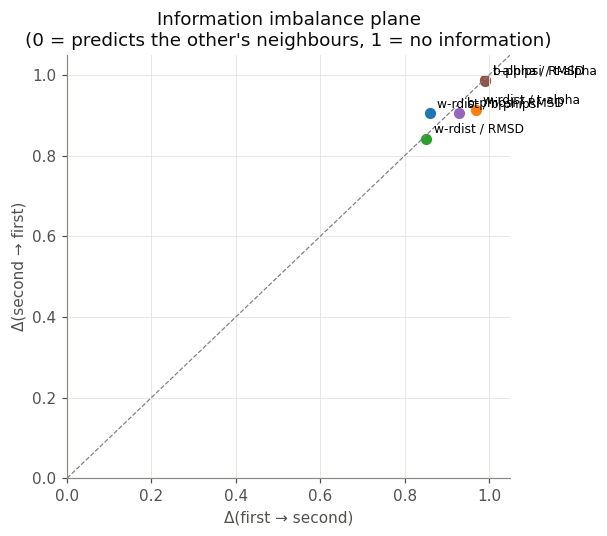

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for i, a in enumerate(LABELS):
    for j, b in enumerate(LABELS):
        if j <= i:
            continue
        x, y = ii_mean.loc[a, b], ii_mean.loc[b, a]
        ax.scatter(x, y, s=40)
        ax.annotate(
            f"{a} / {b}", (x, y), textcoords="offset points", xytext=(5, 4), fontsize=8
        )
ax.plot([0, 1.05], [0, 1.05], color="grey", lw=0.8, ls="--")
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Δ(first → second)")
ax.set_ylabel("Δ(second → first)")
ax.set_title(
    "Information imbalance plane\n(0 = predicts the other's neighbours, 1 = no information)"
)
save(fig, "information_imbalance_plane")

## 1b. Robustness: one comparison per protein

Same table, but each point is ONE comparison of ONE protein (about 150 points, 20 random draws), so the points do not share structures.
If the picture changes (for example w-rdist and RMSD stop sharing information), the subsample result above was an effect of repeated proteins.
k = 1 here, as in the table above.

In [5]:
draws = []
for seed in range(20):
    idx = one_per_protein(info, seed)
    draws.append(
        imbalance_table(Z_all[idx], METRICS, np.random.default_rng(seed))
        .astype(float)
        .values
    )
draws = np.stack(draws)
protein_mean = pd.DataFrame(np.nanmean(draws, axis=0), index=labels, columns=labels)
protein_sd = pd.DataFrame(np.nanstd(draws, axis=0), index=labels, columns=labels)
print(f"{len(idx)} points (one per protein) x 20 draws")
pd.DataFrame(
    [
        [
            (
                f"{protein_mean.iloc[i, j]:.2f} ± {protein_sd.iloc[i, j]:.2f}"
                if np.isfinite(protein_mean.iloc[i, j])
                else "–"
            )
            for j in range(len(labels))
        ]
        for i in range(len(labels))
    ],
    index=labels,
    columns=labels,
)

151 points (one per protein) x 20 draws


,w-rdist,b-phipsi,t-alpha,RMSD,all four
w-rdist,–,0.91 ± 0.05,1.00 ± 0.05,0.85 ± 0.08,0.66 ± 0.05
b-phipsi,0.91 ± 0.04,–,0.98 ± 0.05,0.91 ± 0.06,0.67 ± 0.04
t-alpha,0.98 ± 0.06,0.97 ± 0.06,–,0.99 ± 0.05,0.76 ± 0.06
RMSD,0.85 ± 0.05,0.88 ± 0.06,0.96 ± 0.04,–,0.62 ± 0.04
all four,0.29 ± 0.02,0.28 ± 0.02,0.32 ± 0.03,0.27 ± 0.02,–


---
## 2. Which metrics are redundant? (DII on the four metrics themselves)

Target space = all four metrics. DADApy's backward selection drops one metric at a time and keeps the
four best sets of each size — with four metrics, effectively every set is tried — so the table gives the
best set of 3, 2 and 1 metrics. A metric missing from the best smaller sets is **redundant** given the
others: its neighbourhoods are already there. A metric that every good set keeps is one the others
cannot reproduce — because it sees something they do not, *or* because it is noisy; this section cannot
tell the two apart. About 3 minutes per seed.

In [6]:
rows, t0 = [], time.time()
for seed in SEEDS:
    Z = Z_all[subsample(len(Z_all), N_POINTS, seed)]
    dii = DiffImbalance(
        Z,
        Z,
        num_epochs=150,
        learning_rate=0.05,
        k_init=K,
        k_final=K,
        point_adapt_lambda=True,
        params_init=np.ones(4),
        seed=seed,
    )
    with quiet():
        dii.train()
        sets, diis, errors, weights = dii.backward_greedy_feature_selection(
            n_features_min=1, n_best=4
        )
    for kept, value in zip(sets, diis):
        rows.append(
            {
                "seed": seed,
                "n_metrics": len(kept),
                "kept": " + ".join(LABELS[i] for i in sorted(kept)),
                "dii": float(value),
            }
        )
greedy = pd.DataFrame(rows)
print(f"{time.time() - t0:.0f} s")
greedy_summary = (
    greedy.groupby(["n_metrics", "kept"])["dii"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("n_metrics", ascending=False)
)
greedy_summary.round(3)

257 s


,n_metrics,kept,mean,std,count
3,4,w-rdist + b-phipsi + t-alpha + RMSD,0.009,0.000,3
2,3,b-phipsi + t-alpha + RMSD,0.142,0.003,3
1,2,t-alpha + RMSD,0.365,0.011,3
0,1,RMSD,0.630,0.013,3


---
## 3. Can the Machaon metrics reproduce RMSD?

Here the target is independent of the inputs: the three Machaon metrics (weighted by DII) → RMSD's
neighbourhoods. RMSD is the residue-level deviation after superposition; the Machaon metrics compare
whole-structure summaries. A DII near 0 would mean the Machaon metrics order the comparisons the way
RMSD does; a DII near 1 that they see other things. The learned weights say which Machaon metric comes
closest to RMSD.

In [7]:
rows, curves = [], {}
for seed in SEEDS:
    Z = Z_all[subsample(len(Z_all), N_POINTS, seed)]
    dii = DiffImbalance(
        Z[:, :3],
        Z[:, 3:4],
        num_epochs=150,
        learning_rate=0.05,
        k_init=K,
        k_final=K,
        point_adapt_lambda=True,
        params_init=np.ones(3),
        seed=seed,
    )
    with quiet():
        w_hist, d_hist = dii.train()
        final, error = dii.return_final_dii()
    w = np.abs(np.asarray(w_hist[-1]))
    rows.append(
        {
            "seed": seed,
            "dii": float(final),
            "error": float(error),
            **{LABELS[i]: w[i] / w.max() for i in range(3)},
        }
    )
    if seed == 0:
        curves = (np.asarray(w_hist), np.asarray(d_hist))
machaon = pd.DataFrame(rows)
machaon[["dii", *LABELS[:3]]].agg(["mean", "std"]).round(3)

,dii,w-rdist,b-phipsi,t-alpha
mean,0.788,1.0,0.945,0.905
std,0.013,0.0,0.020,0.054


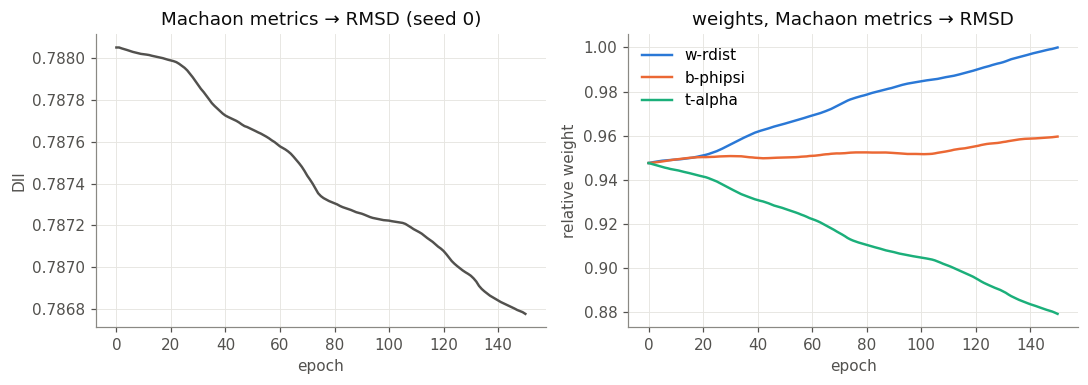

In [8]:
w_hist, d_hist = curves
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(d_hist, color=COLOR["muted"])
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("DII")
axes[0].set_title("Machaon metrics → RMSD (seed 0)")
for i, color in enumerate(["#2a78d6", "#eb6834", "#1baf7a"]):
    axes[1].plot(
        np.abs(w_hist[:, i]) / np.abs(w_hist[-1]).max(), color=color, label=LABELS[i]
    )
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("relative weight")
axes[1].legend()
axes[1].set_title("weights, Machaon metrics → RMSD")
fig.tight_layout()
save(fig, "dii_machaon_to_rmsd")

### 3b. Is t-alpha's "unique information" orientation noise?

If what t-alpha carries beyond the other metrics is mostly the orientation noise measured in notebook
03, then removing the noise (principal-axes frame) should make t-alpha *more* predictable from the
other metrics. Δ(other metrics → t-alpha) in Machaon's frame vs in the principal-axes frame, on the
same comparisons (three subsamples). Needs `results/t_alpha_pca.csv` (notebook 03, section 2b).

In [9]:
PCA_CSV = "results/t_alpha_pca.csv"
tpca = None
if os.path.exists(PCA_CSV):
    pca = pd.read_csv(PCA_CSV)
    pca = pca[(pca["status"] == "ok") & (pca["category"] != "nmr_intra_ensemble")]
    pca = pca.drop_duplicates(["protein_name", "comparison"]).set_index(
        ["protein_name", "comparison"]
    )["t_alpha_pca"]
    keys = list(zip(info["protein_name"], info["comparison"]))
    t_pca = pd.Series(keys).map(lambda k: pca.get(k, np.nan)).to_numpy(dtype=float)
    keep = np.isfinite(t_pca)
    others = log_standardise(X[keep][:, [0, 1, 3]])  # w-rdist, b-phipsi, RMSD
    raw_t = log_standardise(X[keep][:, [2]])
    pca_t = log_standardise(t_pca[keep].reshape(-1, 1))
    rows = []
    for seed in SEEDS:
        idx = subsample(int(keep.sum()), N_POINTS, seed)
        rng = np.random.default_rng(seed)
        rows.append(
            {
                "seed": seed,
                "others → t-alpha (Machaon frame)": information_imbalance(
                    others[idx], raw_t[idx], rng
                ),
                "others → t-alpha (principal axes)": information_imbalance(
                    others[idx], pca_t[idx], rng
                ),
                "t-alpha (Machaon frame) → others": information_imbalance(
                    raw_t[idx], others[idx], rng
                ),
                "t-alpha (principal axes) → others": information_imbalance(
                    pca_t[idx], others[idx], rng
                ),
            }
        )
    tpca = pd.DataFrame(rows).drop(columns="seed").agg(["mean", "std"]).round(3)
    display(tpca)
else:
    print(
        "skipped: run notebook 03 (section 2b) first to write results/t_alpha_pca.csv"
    )

,others → t-alpha (Machaon frame),others → t-alpha (principal axes),t-alpha (Machaon frame) → others,t-alpha (principal axes) → others
mean,0.919,0.913,0.941,0.976
std,0.001,0.008,0.021,0.013


---
## 4. Which protein properties go with a prediction far from the experiments?

Points = the proteins. A = protein properties: the model's confidence (mean pLDDT over the model),
length, complex size of the cryo-EM entry, X-ray available, share of entries released before the AF2
training cutoff, **largest length gap among the protein's pairs (coverage)**, and the experimental
variability in each metric. B = the prediction's distance to the experimental structures (the four
metrics, per protein). Backward selection with DII (two best sets kept per size): which property, alone
or in a small set, best predicts the neighbourhoods of B? All proteins are used, so the result does not depend on a seed.
Small data set (k = 7 ≈ 5 %): exploratory. About 1.5 min per prediction.

In [10]:
pt = protein_table(records_all)
es = experimental_structures(records_all)
cov = protein_covariates(pt, es, length_gaps=protein_max_gap(records_all)).set_index(
    "protein_name"
)
pt = pt.set_index("protein_name")


def prepare(columns):
    A = cov[columns].copy()
    for c in columns:
        if c in ("length", "cryoem_chains"):
            A[c] = np.log10(A[c])
        if c.startswith("exp_"):
            A[c] = np.log10(A[c] + 1e-4)
    A = A.fillna(A.median())
    return (A - A.mean()) / A.std()


rows = []
for pred in ("af2", "of3"):
    features = [
        f"plddt_{pred}",
        "length",
        "cryoem_chains",
        "has_xray",
        "frac_before_af2_cutoff",
        "max_length_gap",
        *[f"exp_{m}" for m in METRICS],
    ]
    labels_f = [f.replace(f"plddt_{pred}", "plddt") for f in features]
    target = pt[[f"{m}__{pred}" for m in METRICS]].dropna()
    A = prepare(features).loc[target.index].values
    B = log_standardise(target.values)
    dii = DiffImbalance(
        A,
        B,
        num_epochs=100,
        learning_rate=0.05,
        k_init=7,
        k_final=7,
        point_adapt_lambda=True,
        params_init=np.ones(len(features)),
        seed=0,
    )
    with quiet():
        dii.train()
        sets, diis, errors, weights = dii.backward_greedy_feature_selection(
            n_features_min=1, n_best=2
        )
    for kept, value in zip(sets, diis):
        if len(kept) <= 3 or len(kept) == len(features):
            rows.append(
                {
                    "prediction": pred.upper(),
                    "n_properties": len(kept),
                    "kept": (
                        "all"
                        if len(kept) == len(features)
                        else " + ".join(labels_f[i] for i in sorted(kept))
                    ),
                    "dii": round(float(value), 3),
                }
            )
props_summary = pd.DataFrame(rows).sort_values(
    ["prediction", "n_properties"], ascending=[True, False]
)
props_summary

,prediction,n_properties,kept,dii
0,AF2,10,all,0.440
1,AF2,3,has_xray + max_length_gap + exp_rmsd,0.522
2,AF2,2,plddt + length,0.588
3,AF2,1,plddt,0.739
4,OF3,10,all,0.481
5,OF3,3,plddt + has_xray + exp_w_rdist_norm,0.487
6,OF3,2,plddt + exp_w_rdist_norm,0.547
7,OF3,1,plddt,0.761


---
## 5. Summary

Computed from the sections above.

*Indicative: this reading describes one run of the pipeline. It is not a final result and holds only as far as the outputs above show it.* The reading:

* **Redundancy.** w-rdist and RMSD share part of their neighbourhoods — the closest pair of metrics,
  and the same with one comparison per protein (section 1b). b-phipsi and t-alpha share little with
  anything, and t-alpha stays in the best sets down to two metrics (section 2). Sections 1–2 cannot say
  whether "sharing little" is information or noise.
* **Machaon vs RMSD.** The three Machaon metrics reproduce RMSD's neighbourhoods only partly, with
  similar weights: they describe whole-structure summaries, RMSD the residue-level deviation after
  superposition. They are complementary views — which is why the thesis reports each metric separately
  (Machaon, too, keeps them as separate axes) with RMSD beside them, and does not merge them into one
  score.
* **t-alpha.** In the principal-axes frame t-alpha becomes only slightly more predictable from the
  other metrics (section 3b), so orientation noise explains little of what it does not
  share with them.
* **What goes with a far prediction.** For both predictions the model's own confidence (pLDDT) is the
  most informative single property. For OF3 the best pair adds the experimental variability in w-rdist
  (a protein whose experiments disagree cannot have a prediction close to all of them); for AF2 it adds
  the chain length (section 4). One selection on the proteins of the set, with k = 7 and one seed:
  exploratory, and a ranking to confirm with other seeds before it is reported.

In [11]:
ii = ii_mean
print(
    f"• Information Imbalance w-rdist ↔ RMSD: {ii.loc['w-rdist', 'RMSD']:.2f} / {ii.loc['RMSD', 'w-rdist']:.2f}; "
    f"t-alpha → others {ii.loc['t-alpha', ['w-rdist', 'b-phipsi', 'RMSD']].min():.2f}–{ii.loc['t-alpha', ['w-rdist', 'b-phipsi', 'RMSD']].max():.2f}"
)
best_sets = greedy_summary.sort_values("n_metrics", ascending=False)
print(
    "• Best set of each size, four metrics as target: "
    + " | ".join(f"{r.kept} ({r['mean']:.2f})" for _, r in best_sets.iterrows())
)
print(
    f"• Machaon metrics → RMSD: DII {machaon['dii'].mean():.2f} ± {machaon['dii'].std():.2f}; "
    f"relative weights {', '.join(f'{name} {machaon[name].mean():.2f}' for name in LABELS[:3])}"
)
if tpca is not None:
    print(
        f"• others → t-alpha: Machaon frame {tpca.loc['mean', 'others → t-alpha (Machaon frame)']:.2f}, "
        f"principal axes {tpca.loc['mean', 'others → t-alpha (principal axes)']:.2f}"
    )
for pred in ("AF2", "OF3"):
    sub = props_summary[props_summary["prediction"] == pred].set_index("n_properties")
    print(
        f"• {pred}: all properties DII {sub.loc[sub.index.max(), 'dii']:.2f}; best single property: "
        f"{sub.loc[1, 'kept']} ({sub.loc[1, 'dii']:.2f}); best pair: {sub.loc[2, 'kept']} ({sub.loc[2, 'dii']:.2f})"
    )

out = {
    "points": int(len(X)),
    "subsample": N_POINTS,
    "seeds": SEEDS,
    "k": K,
    "information_imbalance_mean": ii_mean.round(4)
    .where(ii_mean.notna(), None)
    .to_dict(),
    "information_imbalance_sd": ii_sd.round(4).where(ii_sd.notna(), None).to_dict(),
    "greedy_selection": greedy_summary.round(4).to_dict(orient="records"),
    "machaon_to_rmsd": machaon.round(4).to_dict(orient="records"),
    "t_alpha_frame": None if tpca is None else tpca.to_dict(),
    "protein_properties_selection": props_summary.to_dict(orient="records"),
    "versions": {
        "dadapy": md.version("dadapy"),
        "numpy": np.__version__,
        "jax": md.version("jax"),
    },
}
with open("results/metric_information.json", "w") as f:
    json.dump(out, f, indent=2, default=float)
print("saved results/metric_information.json")

• Information Imbalance w-rdist ↔ RMSD: 0.85 / 0.84; t-alpha → others 0.91–0.99
• Best set of each size, four metrics as target: w-rdist + b-phipsi + t-alpha + RMSD (0.01) | b-phipsi + t-alpha + RMSD (0.14) | t-alpha + RMSD (0.37) | RMSD (0.63)
• Machaon metrics → RMSD: DII 0.79 ± 0.01; relative weights w-rdist 1.00, b-phipsi 0.94, t-alpha 0.90
• others → t-alpha: Machaon frame 0.92, principal axes 0.91
• AF2: all properties DII 0.44; best single property: plddt (0.74); best pair: plddt + length (0.59)
• OF3: all properties DII 0.48; best single property: plddt (0.76); best pair: plddt + exp_w_rdist_norm (0.55)
saved results/metric_information.json
